#AI-Based Email Spam Detection and Pattern Analysis

#Import Libraries
pandas (pd) → for handling tabular data (like CSV files).

numpy (np) → for numerical operations and arrays.

matplotlib.pyplot (plt) → for plotting graphs.

seaborn (sns) → advanced plotting (nice graphs for distributions).

re → regular expressions, used for text cleaning.

os → working with directories, file paths.

joblib → saving and loading models.

urlparse → parsing URLs into components (scheme, domain, path, etc.).

train_test_split → splits data into training and testing sets.

TfidfVectorizer → converts text into numeric features using TF-IDF.

TruncatedSVD → reduces dimensionality of large feature sets (used for visualization and Random Forest).

ML models: Logistic Regression, Random Forest, Gradient Boosting, SVM, Naive Bayes, Decision Tree.

KMeans → unsupervised clustering.

Metrics: accuracy, precision, recall, F1, classification report, confusion matrix, ROC curve, AUC.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import joblib

from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.cluster import KMeans
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

##LOAD SPAM DATASET
Loads the Enron email dataset.

df.head() shows the first 5 rows.

In [10]:
df = pd.read_csv("enron_spam_data.csv")

print(df.head())

   Message ID                       Subject  \
0           0  christmas tree farm pictures   
1           1      vastar resources , inc .   
2           2  calpine daily gas nomination   
3           3                    re : issue   
4           4     meter 7268 nov allocation   

                                             Message Spam/Ham        Date  
0                                                NaN      ham  1999-12-10  
1  gary , production from the high island larger ...      ham  1999-12-13  
2             - calpine daily gas nomination 1 . doc      ham  1999-12-14  
3  fyi - see note below - already done .\nstella\...      ham  1999-12-14  
4  fyi .\n- - - - - - - - - - - - - - - - - - - -...      ham  1999-12-14  


##DATA EXPLORATION
Counts how many spam and ham emails exist.

Visualizes the distribution in a bar chart.

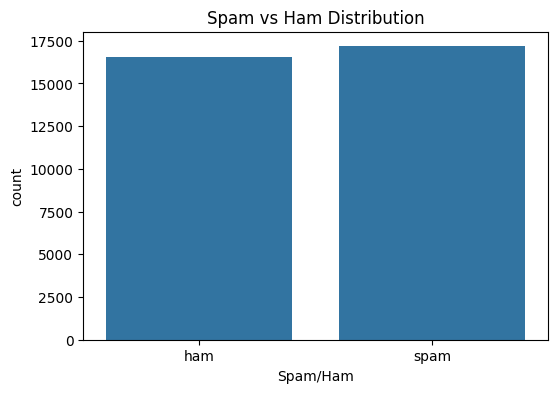

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Spam/Ham', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

##TEXT PREPROCESSING
Combine subject and message into one column.

clean_text: lowercase + remove punctuation/numbers.

Convert target labels to 0 = ham, 1 = spam.

In [12]:
df['combined_text'] = df['Subject'].fillna('') + " " + df['Message'].fillna('')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['cleaned_text'] = df['combined_text'].apply(clean_text)

df['Spam/Ham'] = df['Spam/Ham'].str.strip().str.lower()
df['Spam/Ham'] = df['Spam/Ham'].map({'ham':0,'spam':1})

##TFIDF FEATURE EXTRACTION
Converts text into numeric vectors using TF-IDF.

X → features, y → target labels.

In [13]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.9,
    min_df=5,
    max_features=20000
)

X = vectorizer.fit_transform(df['cleaned_text'])
y = df['Spam/Ham']


##TRAIN TEST SPLIT
80% training, 20% testing.

stratify=y ensures class balance in train/test.

In [14]:

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

##K-MEANS CLUSTERING (UNSUPERVISED LEARNING)
Reduces features to 2 dimensions for visualization.

Performs K-Means clustering (unsupervised) into 2 clusters.


K-MEANS CLUSTERING

Cluster vs Actual (TRAIN DATA):
Spam/Ham      0      1
cluster               
0         12794  13736
1           442      0


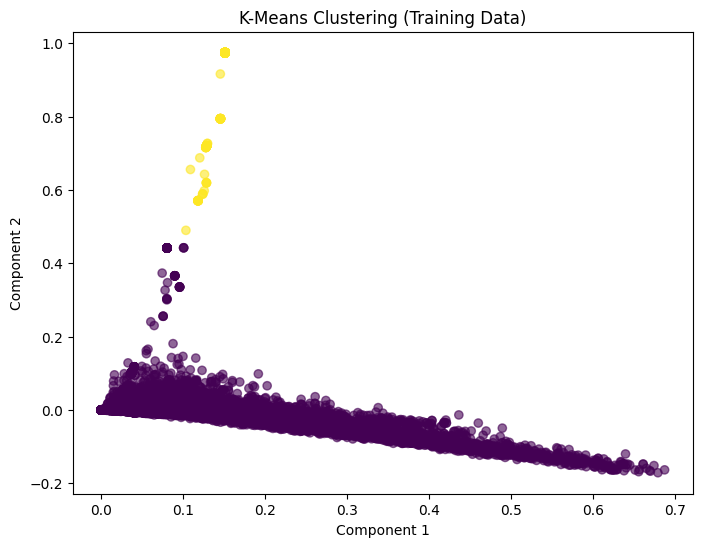

In [15]:
print("\nK-MEANS CLUSTERING")

# Fit ONLY on training data
svd_kmeans = TruncatedSVD(n_components=2, random_state=42)

X_train_k = svd_kmeans.fit_transform(X_train)
X_test_k = svd_kmeans.transform(X_test)

# Train K-Means on training data
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_k)

# Predict clusters ONLY for training data
clusters_train = kmeans.predict(X_train_k)

# Create dataframe for training data only
df_train = df.iloc[y_train.index].copy()
df_train['cluster'] = clusters_train

# Compare clusters with real labels
print("\nCluster vs Actual (TRAIN DATA):")
print(pd.crosstab(df_train['cluster'], df_train['Spam/Ham']))

# Visualization (training data only)
plt.figure(figsize=(8,6))
plt.scatter(X_train_k[:,0], X_train_k[:,1], c=clusters_train, alpha=0.6)
plt.title("K-Means Clustering (Training Data)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

##SPAM MODELS
Trains multiple ML models on spam detection.

In [16]:
models = {

"Logistic Regression": LogisticRegression(max_iter=2000,solver="liblinear"),

"SVM": LinearSVC(),

"Naive Bayes": MultinomialNB(),

"Decision Tree": DecisionTreeClassifier(random_state=42),

"Gradient Boosting": GradientBoostingClassifier(random_state=42)

}

trained_models = {}

for name,model in models.items():

    model.fit(X_train,y_train)

    trained_models[name]=model

##RF WITH SVD
Reduces dimension to 100 using SVD.

Trains Random Forest on reduced features

In [17]:
svd = TruncatedSVD(n_components=100,random_state=42)

X_train_r = svd.fit_transform(X_train)
X_test_r = svd.transform(X_test)

rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_r,y_train)

RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42)

##MODEL EVALUATION


In [18]:
def evaluate_model(model,X_test,y_test,name):

    predictions = model.predict(X_test)

    acc = accuracy_score(y_test,predictions)
    precision = precision_score(y_test,predictions)
    recall = recall_score(y_test,predictions)
    f1 = f1_score(y_test,predictions)

    print("\n===================")
    print(name)
    print("===================")

    print("Accuracy:",acc)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1:",f1)

    print(classification_report(y_test,predictions))

    ConfusionMatrixDisplay.from_predictions(y_test,predictions)

    plt.title(name+" Confusion Matrix")
    plt.show()

    return acc,precision,recall,f1

###RUN SPAM MODEL EVALUATION
Computes accuracy, precision, recall, F1.

Shows confusion matrix.


Logistic Regression
Accuracy: 0.9891755634638197
Precision: 0.9827685238368754
Recall: 0.9962154294032023
F1: 0.9894462917449761
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3309
           1       0.98      1.00      0.99      3435

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744



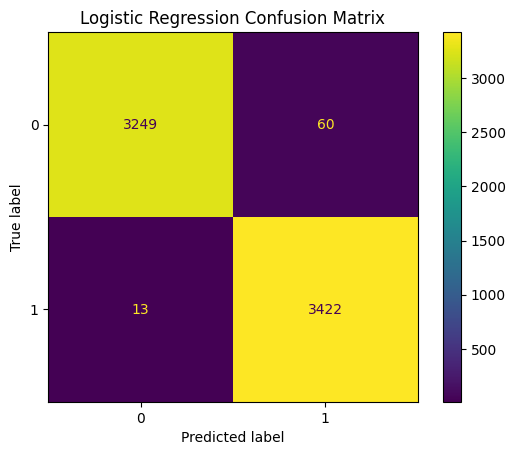


SVM
Accuracy: 0.9930308422301305
Precision: 0.9901620370370371
Recall: 0.9962154294032023
F1: 0.9931795095051517
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3309
           1       0.99      1.00      0.99      3435

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744



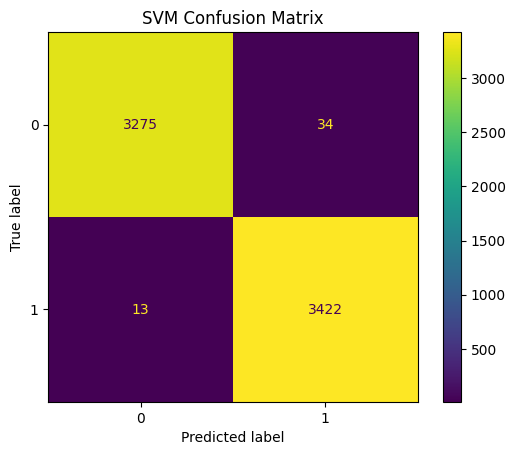


Naive Bayes
Accuracy: 0.9905100830367735
Precision: 0.9881262670141906
Recall: 0.9933042212518195
F1: 0.9907084785133565
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3309
           1       0.99      0.99      0.99      3435

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744



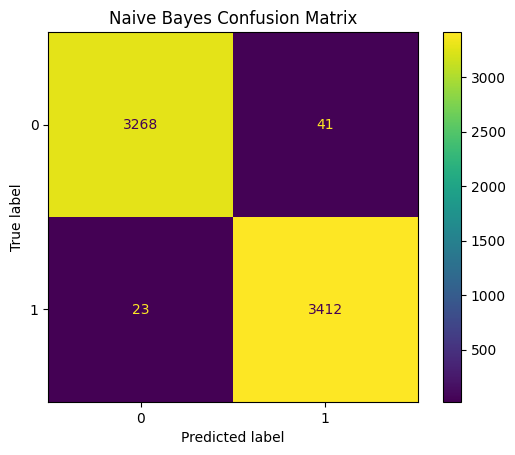


Decision Tree
Accuracy: 0.9663404507710558
Precision: 0.9668218859138533
Recall: 0.9671033478893741
F1: 0.9669625964197351
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3309
           1       0.97      0.97      0.97      3435

    accuracy                           0.97      6744
   macro avg       0.97      0.97      0.97      6744
weighted avg       0.97      0.97      0.97      6744



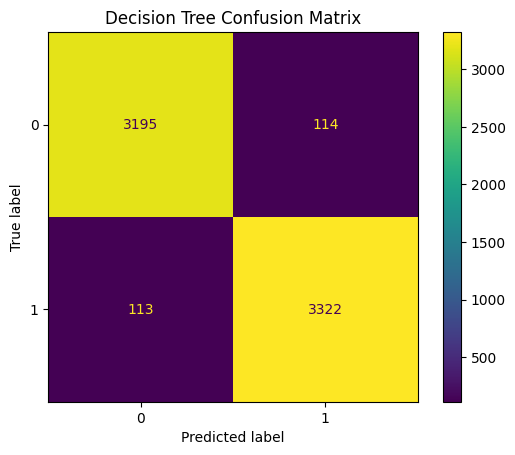


Gradient Boosting
Accuracy: 0.9426156583629893
Precision: 0.906183368869936
Recall: 0.9898107714701602
F1: 0.9461527758452762
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      3309
           1       0.91      0.99      0.95      3435

    accuracy                           0.94      6744
   macro avg       0.95      0.94      0.94      6744
weighted avg       0.95      0.94      0.94      6744



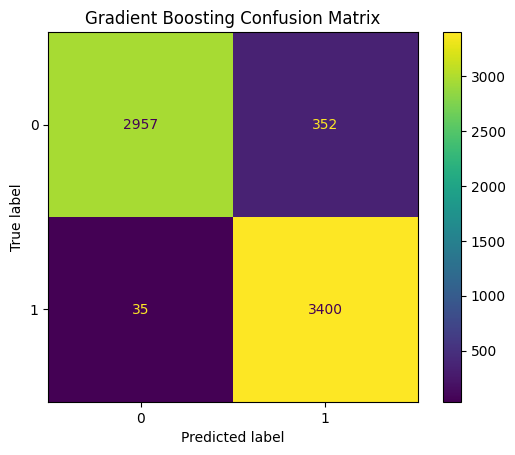


Random Forest
Accuracy: 0.9853202846975089
Precision: 0.979035037334865
Recall: 0.9924308588064047
F1: 0.9856874367500361
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3309
           1       0.98      0.99      0.99      3435

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744



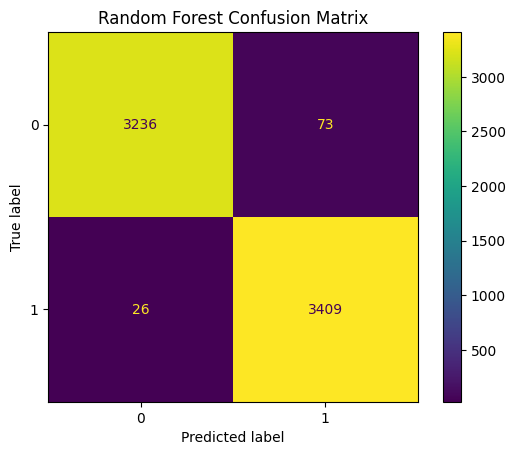

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.989176   0.982769  0.996215  0.989446
1                  SVM  0.993031   0.990162  0.996215  0.993180
2          Naive Bayes  0.990510   0.988126  0.993304  0.990708
3        Decision Tree  0.966340   0.966822  0.967103  0.966963
4    Gradient Boosting  0.942616   0.906183  0.989811  0.946153
5        Random Forest  0.985320   0.979035  0.992431  0.985687


In [19]:
results=[]

for name,model in trained_models.items():

    acc,prec,rec,f1 = evaluate_model(model,X_test,y_test,name)

    results.append([name,acc,prec,rec,f1])

rf_acc,rf_prec,rf_rec,rf_f1 = evaluate_model(
    rf_model,
    X_test_r,
    y_test,
    "Random Forest"
)

results.append(["Random Forest",rf_acc,rf_prec,rf_rec,rf_f1])

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1"]
)

print(results_df)

##ROC CURVE FOR SPAM MODELS
Plots ROC curves and computes AUC to compare models.

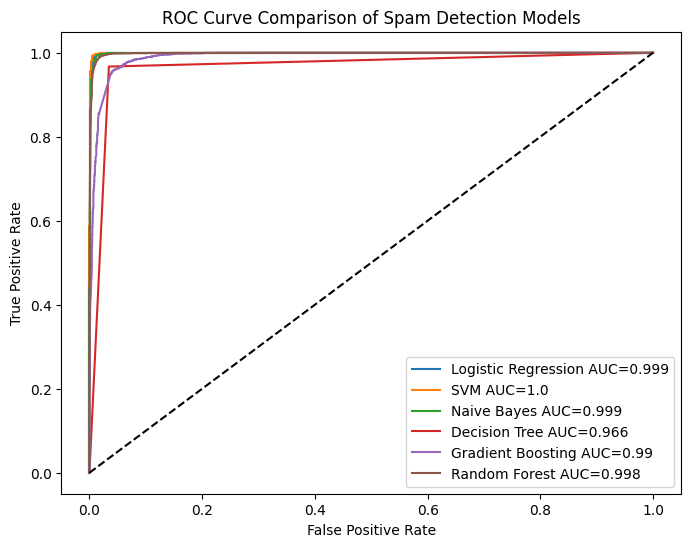

In [20]:
plt.figure(figsize=(8,6))

for name,model in trained_models.items():

    if hasattr(model,"predict_proba"):
        probs = model.predict_proba(X_test)[:,1]

    elif hasattr(model,"decision_function"):
        probs = model.decision_function(X_test)

    else:
        continue

    fpr,tpr,_ = roc_curve(y_test,probs)

    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=name+" AUC="+str(round(roc_auc,3)))

# Random Forest ROC
rf_probs = rf_model.predict_proba(X_test_r)[:,1]

fpr,tpr,_ = roc_curve(y_test,rf_probs)

roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label="Random Forest AUC="+str(round(roc_auc,3)))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Spam Detection Models")

plt.legend()
plt.show()

##SAVE SPAM MODELS
Saves trained model and TF-IDF vectorizer for later use.

In [21]:
os.makedirs("saved_models",exist_ok=True)

joblib.dump(trained_models["Logistic Regression"],"saved_models/spam_logistic.pkl")
joblib.dump(vectorizer,"saved_models/tfidf_vectorizer.pkl")

['saved_models/tfidf_vectorizer.pkl']

##REAL WORLD SPAM PREDICTION
Load model and vectorizer.

Predict whether a new email is spam or ham.

In [22]:
def predict_email_spam(text):

    model = joblib.load("saved_models/spam_logistic.pkl")
    vectorizer = joblib.load("saved_models/tfidf_vectorizer.pkl")

    text = clean_text(text)

    X_input = vectorizer.transform([text])

    prediction = model.predict(X_input)[0]

    return "Spam" if prediction==1 else "Ham"

print(predict_email_spam("URGENT: Your bank account has been suspended. Click here to verify your account immediately."))
print(predict_email_spam("Win a FREE vacation now!!! Limited time offer claim your prize"))
print(predict_email_spam("Hi John, can we schedule the meeting for tomorrow morning?"))
print(predict_email_spam("Please find attached the project report for review."))

Spam
Spam
Ham
Ham


#PHISHING DATASET
Load URL dataset.

Convert labels to 0 (benign) or 1 (phishing).

In [23]:
print("\nPHISHING DETECTION")

phish_df = pd.read_csv("malicious_phish.csv")

phish_df['label'] = phish_df['type'].apply(
    lambda x: 0 if x=="benign" else 1
)


PHISHING DETECTION


##URL FEATURE ENGINEERING
Extract features from URLs (length, dots, digits, suspicious words).

In [24]:
def extract_url_features(url):

    suspicious_words=[
        "login","verify","update","secure",
        "account","bank","paypal","password"
    ]

    return {

        "url_length":len(url),
        "num_dots":url.count('.'),
        "num_hyphens":url.count('-'),
        "num_slashes":url.count('/'),
        "num_digits":sum(c.isdigit() for c in url),
        "has_https":1 if url.startswith("https") else 0,
        "num_at":url.count('@'),
        "num_question":url.count('?'),
        "num_equal":url.count('='),
        "num_ampersand":url.count('&'),

        "has_ip":1 if re.search(r'\d+\.\d+\.\d+\.\d+',url) else 0,

        "has_suspicious_word":int(
            any(word in url.lower() for word in suspicious_words)
        )
    }

url_features = phish_df['url'].apply(lambda x: pd.Series(extract_url_features(x)))

X_url = url_features
y_url = phish_df['label']

##SPLIT

In [25]:
X_train_url,X_test_url,y_train_url,y_test_url = train_test_split(
    X_url,y_url,test_size=0.2,random_state=42,stratify=y_url
)

##PHISHING MODELS
Trains multiple ML models to classify URLs as phishing or legitimate.

In [26]:
phish_models={

"Logistic Regression":LogisticRegression(max_iter=2000),

"SVM":LinearSVC(),

"Naive Bayes":MultinomialNB(),

"Decision Tree":DecisionTreeClassifier(),

"Gradient Boosting":GradientBoostingClassifier(),

"Random Forest":RandomForestClassifier(
    n_estimators=250,
    class_weight="balanced"
)

}

trained_phish_models={}

for name,model in phish_models.items():

    model.fit(X_train_url,y_train_url)

    trained_phish_models[name]=model

##ROC CURVE FOR PHISHING

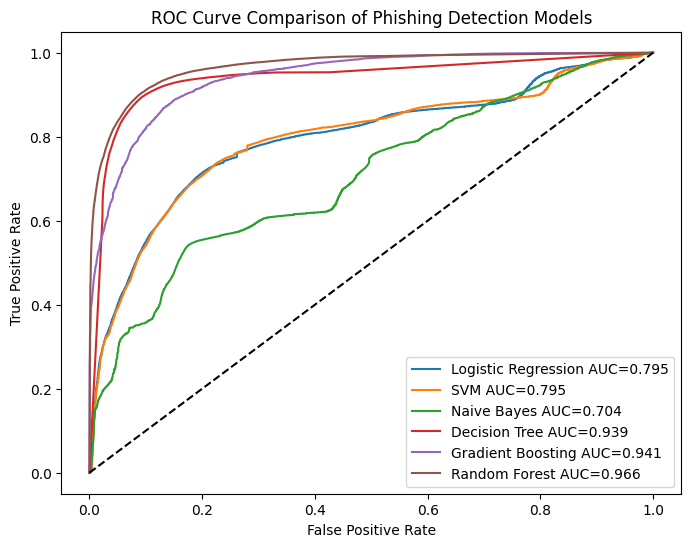

In [27]:
plt.figure(figsize=(8,6))

for name,model in trained_phish_models.items():

    if hasattr(model,"predict_proba"):
        probs = model.predict_proba(X_test_url)[:,1]

    elif hasattr(model,"decision_function"):
        probs = model.decision_function(X_test_url)

    else:
        continue

    fpr,tpr,_ = roc_curve(y_test_url,probs)

    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=name+" AUC="+str(round(roc_auc,3)))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Phishing Detection Models")

plt.legend()
plt.show()

##SAVE BEST MODEL
Save the best performing phishing model (Random Forest).

In [28]:
best_model = trained_phish_models["Random Forest"]

joblib.dump(best_model,"saved_models/phish_best_model.pkl")

['saved_models/phish_best_model.pkl']

##URL PREDICTION

In [29]:
model = joblib.load("saved_models/phish_best_model.pkl")

def predict_phishing_url(url):

    url = url.lower()

    domain = urlparse(url).netloc

    if re.search(r'\d+\.\d+\.\d+\.\d+',domain):
        return "Phishing"

    suspicious_tlds=['.ru','.tk','.ml','.ga','.cf']

    if any(domain.endswith(tld) for tld in suspicious_tlds):
        return "Phishing"

    trusted_domains=[
        "google.com",
        "youtube.com",
        "wikipedia.org",
        "github.com",
        "microsoft.com",
        "amazon.com"
    ]

    for trusted in trusted_domains:

        if domain==trusted or domain.endswith("."+trusted):

            return "Legitimate"

    features = extract_url_features(url)

    X_input = pd.DataFrame([features])

    prediction = model.predict(X_input)[0]

    return "Phishing" if prediction==1 else "Legitimate"

##REAL WORLD URL PREDICTION
Predict if a new URL is phishing or legitimate using the trained model.

Also checks for suspicious IPs, TLDs, and trusted domains before ML prediction

In [30]:
print(predict_phishing_url("http://192.168.0.1/paypal/login"))
print(predict_phishing_url("http://secure-login-paypal-update-account.ru"))
print(predict_phishing_url("https://www.google.com"))
print(predict_phishing_url("https://mail.google.com"))
print(predict_phishing_url("https://wikipedia.org"))
print(predict_phishing_url("https://wikipedia.org.ru"))
print(predict_phishing_url("https://google.com.evil.ru"))

Phishing
Phishing
Legitimate
Legitimate
Legitimate
Phishing
Phishing
